# Spot price and temperature trajectories check

In [2]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
import pandas as pd

###  CARMA parameters $(h^{-1})$

In [18]:
# ------------------------------------------------------------------ CARMA parameters
# Log-price CARMA(5,4)
sig_X = 1

b0 = 4.892284940010e-06
b1 = 0.003871537896
b2 = 0.067247596781
b3 = 0.080860692901
b4 = 1.000000000000

a1 = 0.180878007791
a2 = 0.072955388459
a3 = 0.011876286348
a4 = 0.000206776833
a5 = 7.105208972921e-08

# NIG driver for X  
mu_X = 0.000740454873
delta_X = 0.006870223056
alpha_X = 47.467041650322
beta_X = -5.073598150809


# Temperature CARMA(2,1)
sig_Y = 0.79214262
b0_Y  = 1
b1_Y  = 0.56916278
a1_Y  = 0.90926262
a2_Y  = 0.02497358

# NIG Y
mu_Y    = 0.05744779
delta_Y = 0.90363048
alpha_Y = 0.47208856 
beta_Y  = -0.02994953

# Dimension
pX = 5
pY = 2

# Coupling parameter
gamma = 0                 #to be calibrate                                                     #0.02272844
Gamma = np.array([[0.0],
                  [0.0],
                  [0.0],
                  [0.0],
                  [gamma]])


#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (5, 5)
AX = np.array([[0,         1,          0,         0,         0],
               [0,         0,          1,         0,         0],
               [0,         0,          0,         1,         0],
               [0,         0,          0,         0,         1],
               [-a5,       -a4,       -a3,       -a2,      -a1]])

# Noise vector B_X of shape (5, 1)
BX =  np.array([[0   ], [0   ], [0   ], [0   ], [sig_X]])   

# Selection vector c_X of shape (5, 1)
cX = np.array([b0, b1, b2, b3, b4]) 


#---------------------------------------------------------- Matrices for temperature Y
'''The YUIMA convention holds'''

# Companion matrix A_Y of shape (2, 2)
AY = np.array([[    0,        1  ],
               [-a2_Y,      -a1_Y]])

# Noise vector B_X of shape (2, 1)
BY = np.array([[ 0 ],
               [sig_Y]])   

# Selection vector c_X of shape (5, 1)
cY = np.array([b0_Y, b1_Y]) 

### Usefull parameters

In [19]:
T       = 8760
dt      = 1
n_steps = int(T / dt)

inv_AX = np.linalg.inv(AX)
inv_AY = np.linalg.inv(AY)

exp_AX_dt = expm(AX * dt)
exp_AY_dt = expm(AY * dt)

I_X = np.eye(len(AX))
I_Y = np.eye(len(AY))

MX = (exp_AX_dt - np.eye(len(AX))) @ inv_AX   # (e^{A_X dt} - I) A_X^{-1}
MY = (exp_AY_dt - np.eye(len(AY))) @ inv_AY   # (e^{A_Y dt} - I) A_Y^{-1}


### Seasonal prices

In [20]:
file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values"    : seasonal_series.values,            # return a dictionnary of tuples (m, dow, h)
                        "month"  : seasonal_series.index.month,       
                        "dow"    : seasonal_series.index.dayofweek,      # 0=monday ... 6=sunday
                        "hour"   : seasonal_series.index.hour})
          .groupby(["month", "dow", "hour"])["values"]                    # for example, (3, 2, 12) stands for 12h on a wednesday in march
          .mean()                                                        # we take the mean of the series values on the same dayofweek, hour, month
          .to_dict())

def Lambda_S(t):                                            # consistent with Paraschiv's method
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)

### Normal Inverse Gaussian Lévy increments

In [21]:
# See the method on my notes

def sample_inverse_gaussian(delta, gamma, size):
    M = np.random.randn(*size)                     # M ~ N(0,1)    
    V = M**2                                       # V ~ χ²(1) (chi square law with 1 degree of freedom)

    X_1 = (delta / gamma                           # First solution of the quadratic equation V = [(gamma . X - delta)^2]/X
          + V / (2 * gamma**2)
          - np.sqrt(delta * V / gamma**3 + (V / (2 * gamma**2))**2))                                  
           
    X_2 = (delta / gamma)**2 / X_1                 # Second solution
    
    U  = np.random.uniform(size=size)              # U ~ U[0,1]
    return np.where(U <= delta / (delta + gamma * X_1), X_1, X_2) # return X_1 if U <= mu_ig / (mu_ig + X_1), else return X_2

# X ~ NIG(alpha, beta, delta, mu) if X = mu + beta Y + sqrt(Y) N 
# where N ~ N(0,1)
# and Y ~ IG(delta, gamma), with gamma = sqrt[alpha^2 - beta^2]

def sample_nig(alpha, beta, delta, mu, size):
    gamma = np.sqrt(alpha**2 - beta**2)
    Y = sample_inverse_gaussian(delta, gamma, size=size)
    N = np.random.randn(*size)
    return mu + beta * Y + np.sqrt(Y) * N

np.random.seed(42)

dLX = sample_nig(
    alpha    = alpha_X,
    beta     = beta_X,
    delta = delta_X * dt, # * dt
    mu    = mu_X  * dt  , # * dt
    size     = (n_steps, 1))

dLY = sample_nig(
    alpha    = alpha_Y,
    beta     = beta_Y,
    delta = delta_Y * dt, # * dt
    mu    = mu_Y    * dt, # * dt
    size     = (n_steps, 1))


### Paths trajectories

In [22]:
ZX_path = np.zeros((n_steps + 1, pX))
ZY_path = np.zeros((n_steps + 1, pY))

for t in range(n_steps):
    ZX_path[t+1] = (exp_AX_dt @ ZX_path[t]
                    + MX @ BX @ dLX[t]
                    + MX @ Gamma @ dLY[t])

    ZY_path[t+1] = (exp_AY_dt @ ZY_path[t]
                    + MY @ BY @ dLY[t])

X_path = ZX_path @ cX
Y_path = ZY_path @ cY


### Graphs

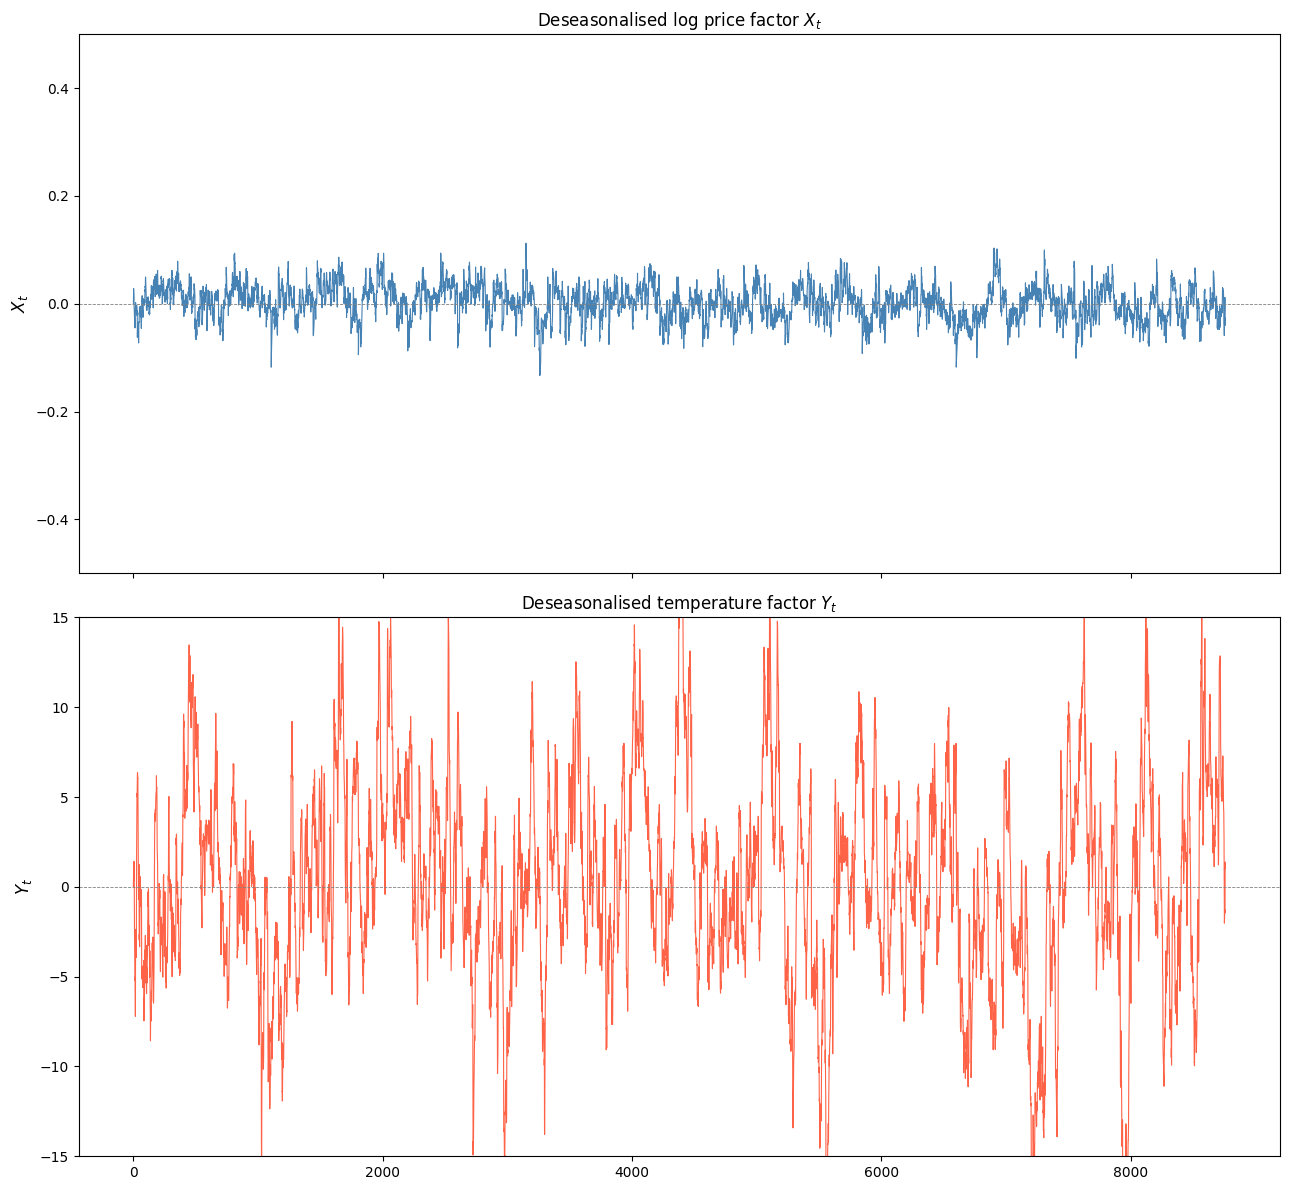

In [23]:
time_days = np.arange(n_steps + 1)

fig, axes = plt.subplots(2, 1, figsize=(13, 12), sharex=True)

axes[0].plot(time_days, X_path, color='steelblue', lw=0.8)
axes[0].axhline(0, color='gray', lw=0.6, ls='--')
axes[0].set_ylabel('$X_t$', fontsize=12)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_title('Deseasonalised log price factor $X_t$')

axes[1].plot(time_days, Y_path, color='tomato', lw=0.8)
axes[1].axhline(0, color='gray', lw=0.6, ls='--')
axes[1].set_ylabel('$Y_t$', fontsize=12)
axes[1].set_ylim(-15, 15)

axes[1].set_title('Deseasonalised temperature factor $Y_t$')

'''
axes[2].plot(time_days[1:], dLX.flatten(),
             color='steelblue', lw=0.5, alpha=0.8, label='$dL^X$')
axes[2].axhline(0, color='gray', lw=0.6, ls='--')
axes[2].set_ylabel('$dL^X_t$', fontsize=12)
axes[2].set_title('Log price NIG process')

axes[3].plot(time_days[1:], dLY.flatten(),
             color='tomato', lw=0.5, alpha=0.8, label='$dL^Y$')
axes[3].axhline(0, color='gray', lw=0.6, ls='--')
axes[3].set_ylabel('$dL^Y_t$', fontsize=12)
axes[3].set_title('Temperature NIG process')
axes[3].set_xlabel('Hours', fontsize=12)
'''
plt.tight_layout()
plt.show()

## Temperature deterministic part : Trend + Seasonal part 

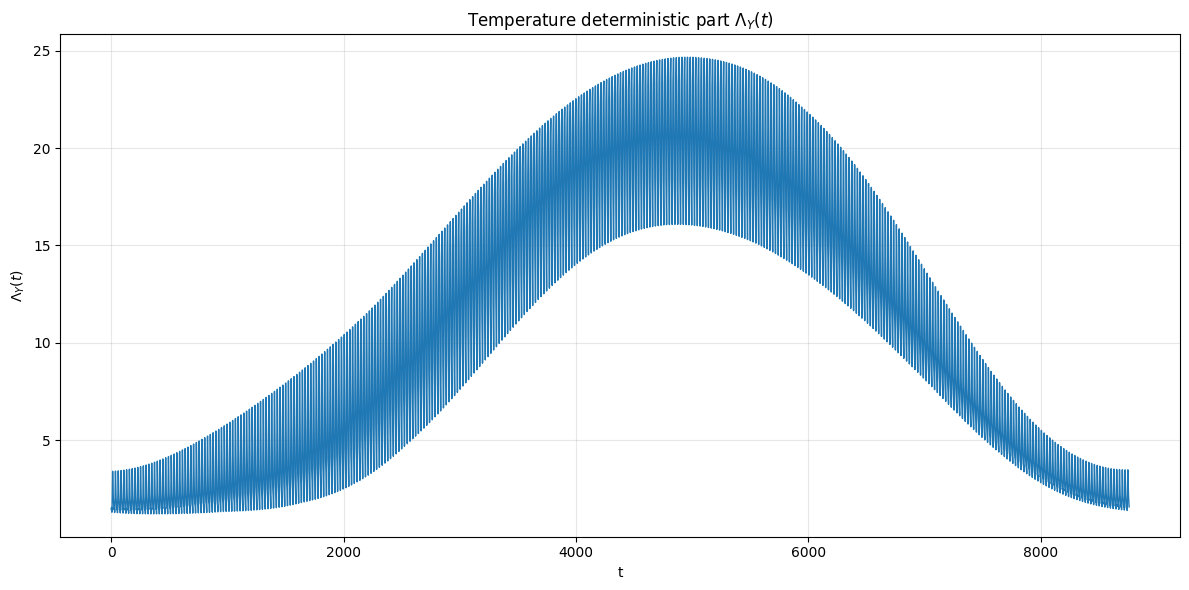

In [24]:

# Coefficients from Gabriel's calibration


params = {
    "intercept": 10.690454,
    "trend": 0.000009,

    "day_cos_1": -2.773715,
    "day_sin_1": -1.343266,
    "day_cos_2": 0.531358,
    "day_sin_2": 0.000696,
    "day_cos_3": 0.138540,
    "day_sin_3": 0.080035,

    "year_cos_1": -8.946296,
    "year_sin_1": -3.018553,
    "year_cos_2": 0.302592,
    "year_sin_2": 0.767941,
    "year_cos_3": 0.010468,
    "year_sin_3": 0.349874,
}

inter = {
    (0,0): 1.607171, (0,1): -0.312688, (0,2): 0.475547, (0,3): -0.059336, (0,4): -0.078006, (0,5): 0.022845,
    (1,0): 0.756810, (1,1): -0.159529, (1,2): 0.259840, (1,3): -0.126255, (1,4): -0.034853, (1,5): 0.044449,
    (2,0): 0.223024, (2,1): -0.054528, (2,2): -0.334527, (2,3): 0.106636, (2,4): -0.053900, (2,5): -0.004609,
    (3,0): 0.260987, (3,1): 0.050532, (3,2): -0.079633, (3,3): 0.099711, (3,4): -0.034754, (3,5): -0.016093,
    (4,0): -0.384988, (4,1): 0.065902, (4,2): -0.028586, (4,3): 0.012953, (4,4): 0.080202, (4,5): -0.035199,
    (5,0): -0.039476, (5,1): -0.000543, (5,2): -0.019505, (5,3): 0.012494, (5,4): -0.001817, (5,5): -0.029581
}


P_DAY = 24
P_YEAR = 365.25 * 24

def day_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_DAY),
        np.sin(2*np.pi*1*t/P_DAY),
        np.cos(2*np.pi*2*t/P_DAY),
        np.sin(2*np.pi*2*t/P_DAY),
        np.cos(2*np.pi*3*t/P_DAY),
        np.sin(2*np.pi*3*t/P_DAY),
    ])

def year_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_YEAR),
        np.sin(2*np.pi*1*t/P_YEAR),
        np.cos(2*np.pi*2*t/P_YEAR),
        np.sin(2*np.pi*2*t/P_YEAR),
        np.cos(2*np.pi*3*t/P_YEAR),
        np.sin(2*np.pi*3*t/P_YEAR),
    ])

# ----------------------------
# Function that enable to evaluate Λ_Y(T)
# ----------------------------
def temperature_deterministic_part(t):
    x = t

    # trend + intercept
    y = params["intercept"] + params["trend"] * x

    # day terms
    y += params["day_cos_1"] * np.cos(2*np.pi*1*x/P_DAY)
    y += params["day_sin_1"] * np.sin(2*np.pi*1*x/P_DAY)
    y += params["day_cos_2"] * np.cos(2*np.pi*2*x/P_DAY)
    y += params["day_sin_2"] * np.sin(2*np.pi*2*x/P_DAY)
    y += params["day_cos_3"] * np.cos(2*np.pi*3*x/P_DAY)
    y += params["day_sin_3"] * np.sin(2*np.pi*3*x/P_DAY)

    # year terms
    y += params["year_cos_1"] * np.cos(2*np.pi*1*x/P_YEAR)
    y += params["year_sin_1"] * np.sin(2*np.pi*1*x/P_YEAR)
    y += params["year_cos_2"] * np.cos(2*np.pi*2*x/P_YEAR)
    y += params["year_sin_2"] * np.sin(2*np.pi*2*x/P_YEAR)
    y += params["year_cos_3"] * np.cos(2*np.pi*3*x/P_YEAR)
    y += params["year_sin_3"] * np.sin(2*np.pi*3*x/P_YEAR)

    # interactions
    d = day_features(x)
    v = year_features(x)

    for (i, j), c in inter.items():
        y += c * d[i] * v[j]

    return y

n = 1
x = np.arange(0, 8760*n, 1)
y = temperature_deterministic_part(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y, linewidth=1)

plt.title(f"Temperature deterministic part $Λ_Y(t)$")
plt.xlabel("t")
plt.ylabel("$Λ_Y(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### One Temperature path vs seasonal trend 

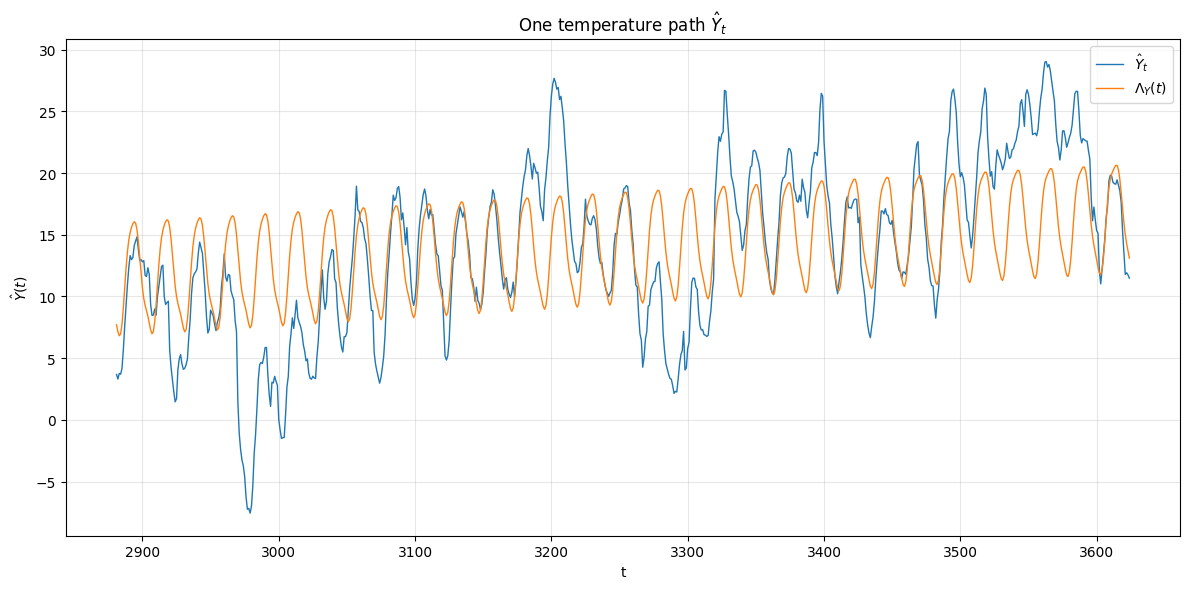

In [25]:
year_start = pd.Timestamp("2026-01-01 00:00:00", tz="UTC")
start = pd.Timestamp("2026-05-01 00:00:00", tz="UTC")
end   = pd.Timestamp("2026-06-01 00:00:00", tz="UTC")

start_index = int((start - year_start).total_seconds() / 3600) + 1
end_index   = int((end   - year_start).total_seconds() / 3600) + 1


x = np.arange(start_index, end_index, 1)
y = temperature_deterministic_part(x) + Y_path[start_index:end_index]
z = temperature_deterministic_part(x)
plt.figure(figsize=(12, 6))
plt.plot(x, y, linewidth=1, label="$\hat{Y}_t$")
plt.plot(x, z, linewidth=1, label="$\Lambda_Y (t)$")
plt.legend()
plt.title("One temperature path $\hat{Y}_t$ ")
plt.xlabel("t")
plt.ylabel("$\hat{Y}(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### One spot price path vs seasonal trend

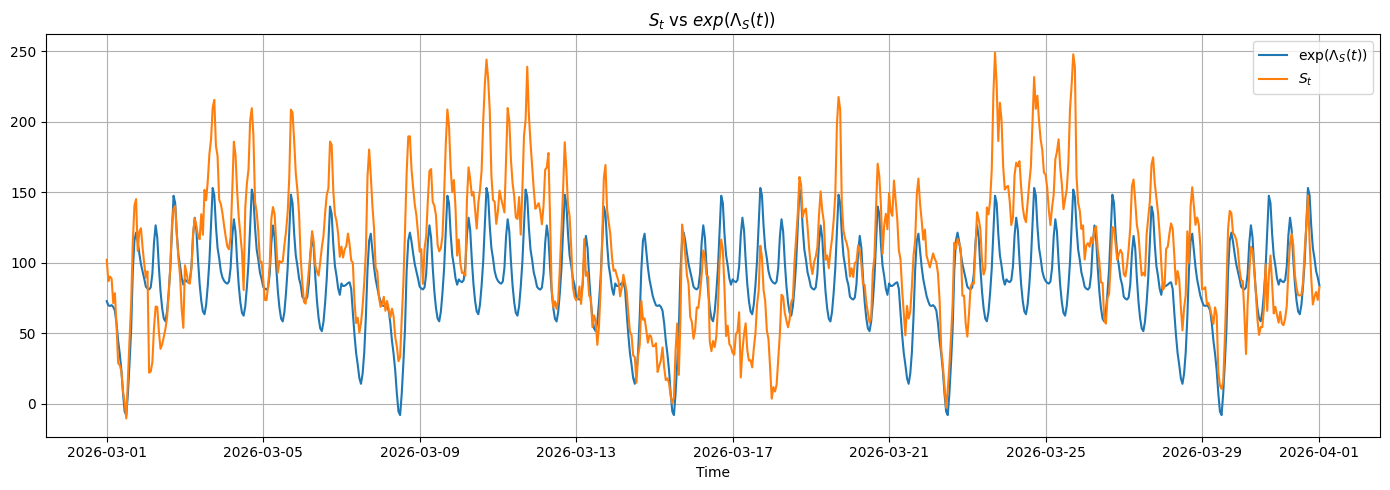

In [26]:
year_start = pd.Timestamp("2026-01-01 00:00:00", tz="UTC")
start = pd.Timestamp("2026-03-01 00:00:00", tz="UTC")
end   = pd.Timestamp("2026-04-01 00:00:00", tz="UTC")

dates = pd.date_range(start=start, end=end, freq="h", tz="UTC")

start_index = int((start - year_start).total_seconds() / 3600)
end_index   = int((end   - year_start).total_seconds() / 3600) 

lambda_S_values = np.array([Lambda_S(t) for t in dates])
X_values = np.array(X_path[start_index:end_index + 1])

exp_lambda_S = np.exp(lambda_S_values) - 1000
S_t = np.exp(X_values + lambda_S_values) - 1000


series = pd.Series(exp_lambda_S, index=dates)
series2 = pd.Series(S_t, index=dates)
plt.figure(figsize=(14,5))
plt.plot(series.index, series.values, label="$\exp(\Lambda_S(t))$")
plt.plot(series2.index, series2.values, label="$S_t$")
plt.legend()
plt.title(f"$S_t$ vs $exp(\Lambda_S(t))$ ")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()